In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [64]:
#LOADING DATA
df=pd.read_csv('/content/spam.csv')
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [65]:
df.head()


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [66]:
df = df[["Category", "Message"]]
df.head(

)

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [67]:
df.columns=["label","text"]

In [68]:
df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

In [69]:
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [70]:
#checking for missing values
missing_val=df.isnull().sum()
missing_val

,0
label,0
text,0


In [71]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [72]:
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenize
    words = text.split()

    # Remove stopwords
    words = [word for word in words
             if word not in stopwords.words("english")]

    # Lemmatization
    words = [lemmatizer.lemmatize(word)
             for word in words]

    return " ".join(words)

In [73]:
df["clean_text"] = df["text"].apply(clean_text)

In [74]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=3000)

X = vectorizer.fit_transform(df["clean_text"]).toarray()

y = df["label"].values

In [75]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42

)

**MODEL BUILDING**

*WEIGHT INITIALIZATION AND FOR PROPAGATION*

In [76]:
input_size=3000
hidden_1=64
hidden_2=32
output_size=1
#USING HE WEIGHT INITIALIZATION TECHNIQUE

w1=np.random.randn(input_size,64)*np.sqrt(2/input_size)
b1=np.zeros((1,64))

w2=np.random.randn(64,32)*np.sqrt(2/hidden_1)
b2=np.zeros((1,32))

w3=np.random.randn(32,1)*np.sqrt(2/hidden_2)
b3=np.zeros((1,1))

In [77]:
#Activation Functions
import numpy as np
def relu(X):
  return np.maximum(0,X)

def sigmoid(X):
  return 1/(1+np.exp(-X))


In [78]:
def for_prop(X, w1, b1, w2, b2, w3, b3):

    z1 = np.dot(X, w1) + b1
    A1 = relu(z1)

    z2 = np.dot(A1, w2) + b2
    A2 = relu(z2)

    z3 = np.dot(A2, w3) + b3
    A3 = sigmoid(z3)

    return z1, A1, z2, A2, z3, A3

In [79]:
print(X_train.shape)
print(w1.shape)
print(b1.shape)

print(w2.shape)
print(b2.shape)

print(w3.shape)
print(b3.shape)

(4457, 3000)
(3000, 64)
(1, 64)
(64, 32)
(1, 32)
(32, 1)
(1, 1)


In [80]:
z1,A1,z2,A2,z3,A3=for_prop(X_train,
                           w1,b1,
                           w2,b2,
                           w3,b3)

*DEFINING LOSS*

In [81]:
print(y_train.shape)
print(A3.shape)

(4457,)
(4457, 1)


In [82]:
y_train = y_train.reshape(-1, 1)

In [83]:
def binary_cross_entropy(y_true,y_pred):
  epsilon=1e-15

  y_pred=np.clip(y_pred,epsilon,1-epsilon)

  loss=np.mean(-y_true*np.log(y_pred)-(1-y_true)*np.log(1-y_pred))
  return loss

In [84]:
loss = binary_cross_entropy(y_train.reshape(-1,1), A3)

print(loss)

0.6999362208549348


*BACKPROPAGATION*

In [96]:
# Output Layer
dz3 = A3 - y_train
m=X_train.shape[0]

dw3 = (1/m) * np.dot(A2.T, dz3)
db3 = (1/m) * np.sum(dz3, axis=0, keepdims=True)


def relu_derivative(X):
  return (X>0).astype(float)

# Hidden Layer 2
dA2 = np.dot(dz3, w3.T)
dz2 = dA2 * relu_derivative(z2)

dw2 = (1/m) * np.dot(A1.T, dz2)
db2 = (1/m) * np.sum(dz2, axis=0, keepdims=True)

# Hidden Layer 1
dA1 = np.dot(dz2, w2.T)
dz1 = dA1 * relu_derivative(z1)

dw1 = (1/m) * np.dot(X_train.T, dz1)
db1 = (1/m) * np.sum(dz1, axis=0, keepdims=True)



In [97]:
def update_param(w1,b1,w2,b2,w3,b3,dw1,db1,dw2,db2,dw3,db3,learning_rate):
  w1-=learning_rate*dw1
  b1-=learning_rate*db1

  w2-=learning_rate*dw2
  b2-=learning_rate*db2

  w3-=learning_rate*dw3
  b3-=learning_rate*db3

  return w1,b2,w2,b2,w3,b3



*TRAINING LOOP*:-**USING MINI BATCH GRADIENT DESCENT**

In [104]:
# Hyperparameters
epochs = 100
batch_size = 32
learning_rate = 0.01

losses = []

for epoch in range(epochs):

    # Shuffle the training data
    indices = np.random.permutation(X_train.shape[0])
    X_shuffled = X_train[indices]
    y_shuffled = y_train[indices]

    epoch_loss = 0

    # Mini-batch loop
    for i in range(0, X_train.shape[0], batch_size):

        # Create mini-batch
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size].reshape(-1,1)

        m = X_batch.shape[0]

        # -------------------------
        # Forward Propagation
        # -------------------------
        z1, A1, z2, A2, z3, A3 = for_prop(
            X_batch,
            w1, b1,
            w2, b2,
            w3, b3
        )

        # -------------------------
        # Compute Loss
        # -------------------------
        loss = binary_cross_entropy(y_batch, A3)
        epoch_loss += loss

        # -------------------------
        # Backpropagation
        # -------------------------

        # Output Layer
        dz3 = A3 - y_batch
        dw3 = (1/m) * np.dot(A2.T, dz3)
        db3 = (1/m) * np.sum(dz3, axis=0, keepdims=True)

        # Hidden Layer 2
        dA2 = np.dot(dz3, w3.T)
        dz2 = dA2 * relu_derivative(z2)

        dw2 = (1/m) * np.dot(A1.T, dz2)
        db2 = (1/m) * np.sum(dz2, axis=0, keepdims=True)

        # Hidden Layer 1
        dA1 = np.dot(dz2, w2.T)
        dz1 = dA1 * relu_derivative(z1)

        dw1 = (1/m) * np.dot(X_batch.T, dz1)
        db1 = (1/m) * np.sum(dz1, axis=0, keepdims=True)

        # -------------------------
        # Gradient Descent Update
        # -------------------------

        w1 -= learning_rate * dw1
        b1 -= learning_rate * db1

        w2 -= learning_rate * dw2
        b2 -= learning_rate * db2

        w3 -= learning_rate * dw3
        b3 -= learning_rate * db3

    # Average loss over all mini-batches
    avg_loss = epoch_loss / (X_train.shape[0] // batch_size)

    losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

Epoch 10/100 | Loss: 0.3782
Epoch 20/100 | Loss: 0.3344
Epoch 30/100 | Loss: 0.2257
Epoch 40/100 | Loss: 0.1336
Epoch 50/100 | Loss: 0.0904
Epoch 60/100 | Loss: 0.0674
Epoch 70/100 | Loss: 0.0525
Epoch 80/100 | Loss: 0.0403
Epoch 90/100 | Loss: 0.0323
Epoch 100/100 | Loss: 0.0260


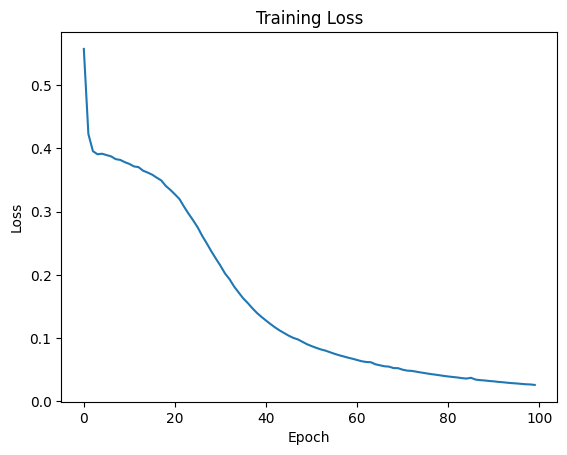

In [105]:
 import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [106]:
#Testing looop
z1, A1, z2, A2, z3, A3 = for_prop(
    X_test,
    w1, b1,
    w2, b2,
    w3, b3
)

In [107]:
y_pred = (A3 >= 0.5).astype(int)

In [110]:
print(confusion_matrix(y_test, y_pred))

[[962   4]
 [ 15 134]]


In [112]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.9829596412556054
Precision: 0.9710144927536232
Recall   : 0.8993288590604027
F1 Score : 0.9337979094076655

Confusion Matrix:
[[962   4]
 [ 15 134]]


In [119]:
message = "Hi John, are we still meeting tomorrow at 10 AM? Let me know."

# Preprocess
message = clean_text(message)

# Convert to TF-IDF
message_vector = vectorizer.transform([message]).toarray()

# Forward Propagation
_, _, _, _, _, pred = for_prop(
    message_vector,
    w1, b1,
    w2, b2,
    w3, b3
)

print("Spam Probability:", pred[0][0])

if pred >= 0.5:
    print("Spam")
else:
    print("Ham")

Spam Probability: 0.00062257919721307
Ham
